<a href="https://colab.research.google.com/github/tai201120112010/Train-Model/blob/main/Train%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
data_folder = './data'

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

100%|██████████| 26.4M/26.4M [00:02<00:00, 8.87MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


In [ ]:
print(tr_images.shape)
print(tr_targets.shape)
print(fmnist.classes)

torch.Size([60000, 28, 28])
torch.Size([60000])
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


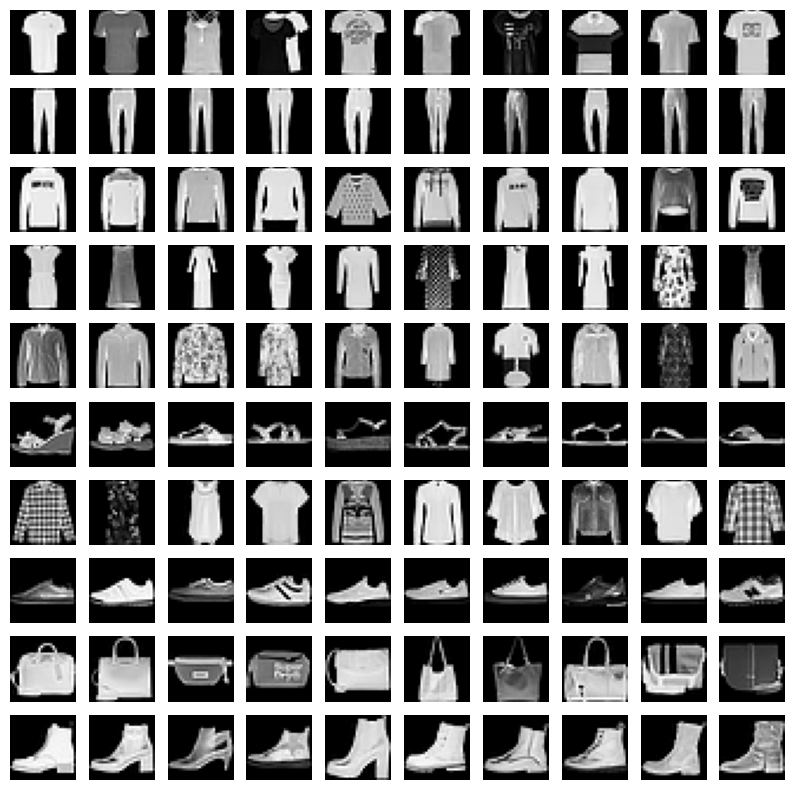

In [ ]:
R, C = 10, 10
fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):

    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:

        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)

        x = tr_images[ix]

        plot_cell.imshow(x, cmap='gray')

plt.show()

In [ ]:
class FMNISTDataset(Dataset):

    def __init__(self, x, y):

        x = x.float()/255
        x = x.view(-1, 28*28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):

        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):

        return len(self.x)
#step 7 tạo dataset -> giúp pytorch đọc dữ liệu

In [ ]:
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    return trn_dl
#step 8 chia dữ liệu ngẫu nhiên thành từng phần

In [ ]:
from torch.optim import SGD

def get_model():

    model = nn.Sequential(

        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)

    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = SGD(
        model.parameters(),
        lr=0.01
    )

    return model, loss_fn, optimizer

In [ ]:
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    loss = loss_fn(prediction, y)

    loss.backward()

    opt.step()

    opt.zero_grad()

    return loss.item()
#step 10 hàm train

In [ ]:
@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()
#step 11 hàm tính accuracy

In [ ]:
for epoch in range(5):

    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.mean(epoch_losses)

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    print(f"Epoch {epoch+1}/5 - Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f}")

Epoch 1/5 - Loss: 0.4192 - Accuracy: 0.8586
Epoch 2/5 - Loss: 0.4066 - Accuracy: 0.8635
Epoch 3/5 - Loss: 0.3959 - Accuracy: 0.8657
Epoch 4/5 - Loss: 0.3850 - Accuracy: 0.8682
Epoch 5/5 - Loss: 0.3772 - Accuracy: 0.8740


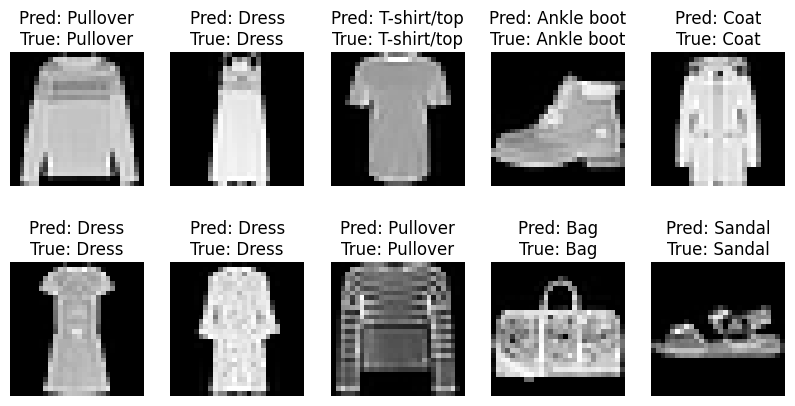

In [ ]:
import random

plt.figure(figsize=(10,5))

for i in range(10):

    idx = random.randint(0,60000)

    image = tr_images[idx].float()/255
    label = tr_targets[idx]

    x = image.view(-1,28*28).to(device)

    prediction = model(x)

    pred_label = prediction.argmax().item()

    plt.subplot(2,5,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Pred: {fmnist.classes[pred_label]}\nTrue: {fmnist.classes[label]}")
    plt.axis("off")

plt.show()

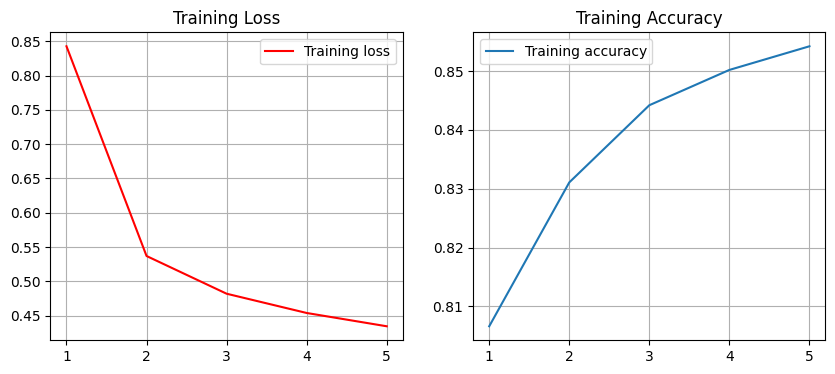

In [ ]:
epochs = np.arange(5)+1

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Training Loss")
plt.plot(epochs, losses, color='red', label="Training loss")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.title("Training Accuracy")
plt.plot(epochs, accuracies, label="Training accuracy")
plt.grid(True)
plt.legend()

plt.show()
#biểu đồ tóm tắt kết quả train: training loss giảm, training accuracy tăng -> train tốt